# Exponential Growth and Decay

This notebook introduces **ordinary differential equations (ODEs)** from first principles — what they are, what a solution means, and how to compute one. We use the exponential ODE $\dot{x} = kx$ as our entry point: it is the simplest nontrivial ODE and the exact solution is known, making it ideal for validating numerical methods.

## What Is an ODE?

A **first-order ordinary differential equation** is an equation of the form

$$\dot{x}(t) \equiv \frac{dx}{dt} = f(x(t), t)$$

where $x : \mathbb{R} \to \mathbb{R}$ is an unknown function of time $t$, and $f$ is a given function. The ODE specifies the **instantaneous rate of change** of $x$ in terms of the current state (and possibly time).

An ODE is called **autonomous** if $f$ does not depend explicitly on $t$: $\dot{x} = f(x)$. In an autonomous system, the rate of change depends only on where you are, not when you are there.

### What Is a Solution?

A **solution** to the ODE with **initial condition** $x(t_0) = x_0$ is a differentiable function $x(t)$ satisfying:
1. $\dfrac{d}{dt}x(t) = f(x(t))$ for all $t$ in some interval, and  
2. $x(t_0) = x_0$.

This is called an **initial value problem (IVP)**. The family of all solutions as $x_0$ varies is called the **flow** of the ODE.

A fundamental theorem (Picard-Lindelöf) guarantees existence and uniqueness of solutions when $f$ is Lipschitz continuous.

## The Exponential ODE: $\dot{x} = kx$

Consider the autonomous IVP

$$\dot{x} = kx, \qquad x(0) = x_0$$

where $k \in \mathbb{R}$ is a constant rate.

### Deriving the Exact Solution

**Separation of variables**: assume $x \neq 0$ and write

$$\frac{dx}{x} = k\, dt$$

Integrate both sides:

$$\ln|x| = kt + C \implies x(t) = e^C \cdot e^{kt}$$

Applying $x(0) = x_0$ gives $e^C = x_0$, so

$$\boxed{x(t) = x_0 \, e^{kt}}$$

### Three Regimes

| $k$ | Behavior | Example |
|-----|----------|--------|
| $k > 0$ | Exponential **growth** — $x \to \infty$ | Population, compound interest |
| $k = 0$ | **Constant** — $x(t) = x_0$ | Static equilibrium |
| $k < 0$ | Exponential **decay** — $x \to 0$ | Radioactive decay, Newton cooling |

For decay, the **half-life** is $t_{1/2} = \dfrac{\ln 2}{|k|}$ — the time for $x$ to decrease by half.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use("dark_background")

## Slope Fields

A **slope field** (direction field) is a visualization of the ODE $\dot{x} = f(x, t)$. At each point $(t, x)$ in the plane we draw a short line segment with slope $f(x, t)$ — this shows which direction any solution curve must travel through that point.

For the autonomous ODE $\dot{x} = kx$, the slope at $(t, x)$ is $kx$, independent of $t$. So slopes are constant along horizontal lines $x = \text{const}$ — the field has no horizontal variation.

We draw the segments as uniform-length arrows using `quiver` with normalized direction vectors $(1, f(x,t)) / \|(1, f(x,t))\|$.

In [13]:
def plot_slope_field(f, t_range, x_range, ax, n=20, color='cyan', alpha=0.5):
    """
    Draw a slope field for the scalar ODE dx/dt = f(t, x).

    At each grid point (t, x), draws a normalized arrow in the direction
    (1, f(t,x)), so all arrows have equal length regardless of magnitude.
    """
    t_vals = np.linspace(*t_range, n)
    x_vals = np.linspace(*x_range, n)
    T, X = np.meshgrid(t_vals, x_vals)
    dX = f(T, X)
    dT = np.ones_like(dX)
    length = np.sqrt(dT**2 + dX**2)
    ax.quiver(T, X, dT / length, dX / length,
              alpha=alpha, color=color,
              headlength=0, headaxislength=0,
              pivot='middle', scale=n * 1.5,
              angles='xy')

## Euler's Method

Given that we cannot always find a closed-form solution, we need **numerical methods** — algorithms that compute approximations $x_0, x_1, x_2, \ldots$ to the true solution at discrete time points $t_0 < t_1 < t_2 < \cdots$.

**Euler's method** is the simplest such algorithm. It comes directly from the definition of the derivative:

$$\frac{dx}{dt}\bigg|_{t=t_k} \approx \frac{x(t_k + h) - x(t_k)}{h}$$

Substituting $\dot{x}(t_k) = f(x_k)$ and solving for $x(t_{k+1})$:

$$\boxed{x_{k+1} = x_k + h \cdot f(x_k)}$$

where $h = t_{k+1} - t_k$ is the **step size**. This is a first-order Taylor approximation: we linearize $x(t)$ over each interval $[t_k, t_{k+1}]$.

**Accuracy**: the local truncation error (error per step) is $O(h^2)$. Accumulated over $T/h$ steps, the **global error** is $O(h)$ — Euler's method is **first-order accurate**. Halving $h$ roughly halves the error.

In [14]:
def euler(f, x0, t0, t_end, h):
    """
    Euler's method for the scalar IVP dx/dt = f(t, x), x(t0) = x0.

    Parameters
    ----------
    f     : callable f(t, x) -> float
    x0    : float, initial condition
    t0    : float, start time
    t_end : float, end time
    h     : float, step size

    Returns
    -------
    ts : 1D array of time points
    xs : 1D array of solution values
    """
    ts = [t0]
    xs = [x0]
    t, x = t0, x0
    while t < t_end - 1e-12:           # avoid floating-point overshoot
        h_actual = min(h, t_end - t)   # don't step past t_end
        x = x + h_actual * f(t, x)
        t = t + h_actual
        ts.append(t)
        xs.append(x)
    return np.array(ts), np.array(xs)

## Comparing Euler to `scipy.integrate.solve_ivp` and the Exact Solution

`scipy.integrate.solve_ivp` uses adaptive Runge-Kutta methods (RK45 by default) — much higher-order and much more accurate than Euler. We use it as the "ground truth" reference.

The plot below shows all three for the decay problem $\dot{x} = -0.5x$, $x(0) = 10$. Notice:
- Large step Euler ($h = 1$) visibly lags behind the true solution.
- Smaller step Euler ($h = 0.1$) is nearly indistinguishable from exact at this scale.
- scipy matches the exact solution perfectly.

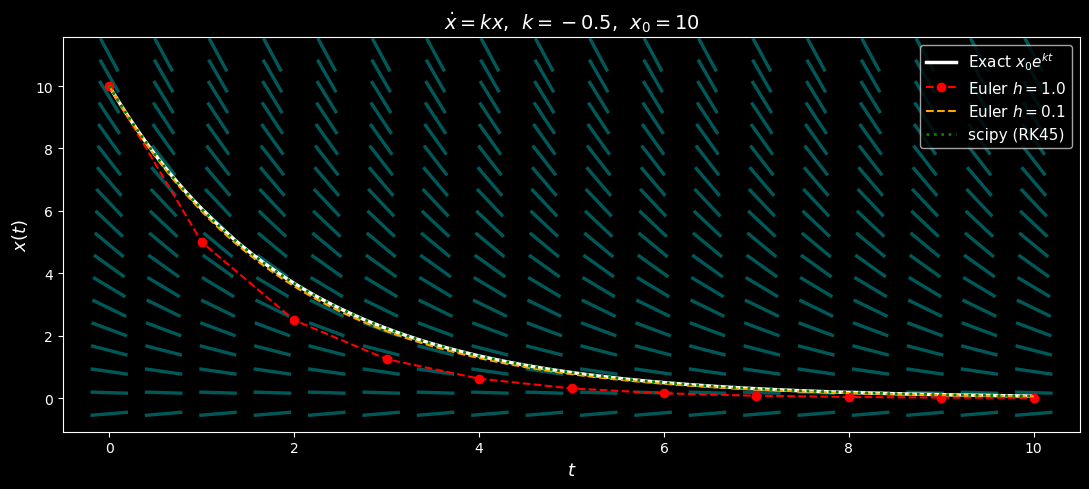

In [15]:
k = -0.5
x0 = 10.0
T = 10.0
f_exp = lambda t, x: k * x

# Exact solution
t_exact = np.linspace(0, T, 400)
x_exact = x0 * np.exp(k * t_exact)

# Euler with two step sizes
t_e1, x_e1 = euler(f_exp, x0, 0, T, h=1.0)
t_e2, x_e2 = euler(f_exp, x0, 0, T, h=0.1)

# scipy solve_ivp (RK45, adaptive step)
sol = solve_ivp(f_exp, (0, T), [x0], dense_output=True)
x_scipy = sol.sol(t_exact)[0]

fig, ax = plt.subplots(figsize=(11, 5))
plot_slope_field(f_exp, (0, T), (-0.5, 11), ax, n=18, alpha=0.35)
ax.plot(t_exact, x_exact,   'w-',       lw=2.5, label=r'Exact $x_0 e^{kt}$')
ax.plot(t_e1,    x_e1,      'r--o',     ms=6,   label='Euler $h = 1.0$')
ax.plot(t_e2,    x_e2,      color='orange', ls='--', lw=1.5, label='Euler $h = 0.1$')
ax.plot(t_exact, x_scipy,   'g:',       lw=2,   label='scipy (RK45)')
ax.set_xlabel('$t$', fontsize=13)
ax.set_ylabel('$x(t)$', fontsize=13)
ax.set_title(r'$\dot{x} = kx$,  $k = -0.5$,  $x_0 = 10$', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Step Size and Accuracy

Since Euler's method is first-order accurate (global error $O(h)$), we expect the error at a fixed time $T$ to decrease **linearly** with $h$. On a log-log plot, this should appear as a straight line with slope 1.

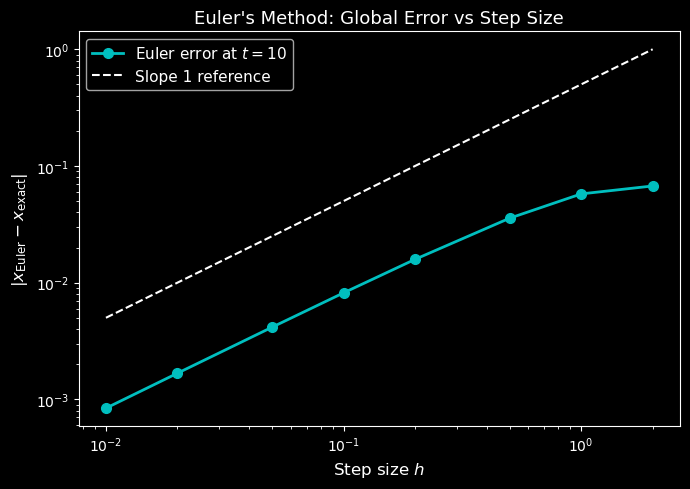

In [16]:
h_vals = [2.0, 1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01]
errors = []

for h in h_vals:
    ts, xs = euler(f_exp, x0, 0, T, h)
    x_true = x0 * np.exp(k * ts[-1])   # exact value at the final time
    errors.append(abs(xs[-1] - x_true))

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h_vals, errors, 'co-', lw=2, ms=7, label="Euler error at $t = 10$")
# Reference line of slope 1
h_ref = np.array([min(h_vals), max(h_vals)])
ax.loglog(h_ref, 0.5 * h_ref, 'w--', lw=1.5, label='Slope 1 reference')
ax.set_xlabel('Step size $h$', fontsize=12)
ax.set_ylabel('$|x_{\\mathrm{Euler}} - x_{\\mathrm{exact}}|$', fontsize=12)
ax.set_title("Euler's Method: Global Error vs Step Size", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The error points lie on the slope-1 reference line, confirming first-order convergence. Each time we halve $h$, the error approximately halves.

## Families of Solutions

The **flow** of $\dot{x} = kx$ is the family $x(t; x_0) = x_0 e^{kt}$. Different initial conditions $x_0$ produce parallel exponential curves (exponential growth) or decay curves (exponential decay). The slope field shows that solution curves never cross — this is a consequence of the uniqueness theorem.

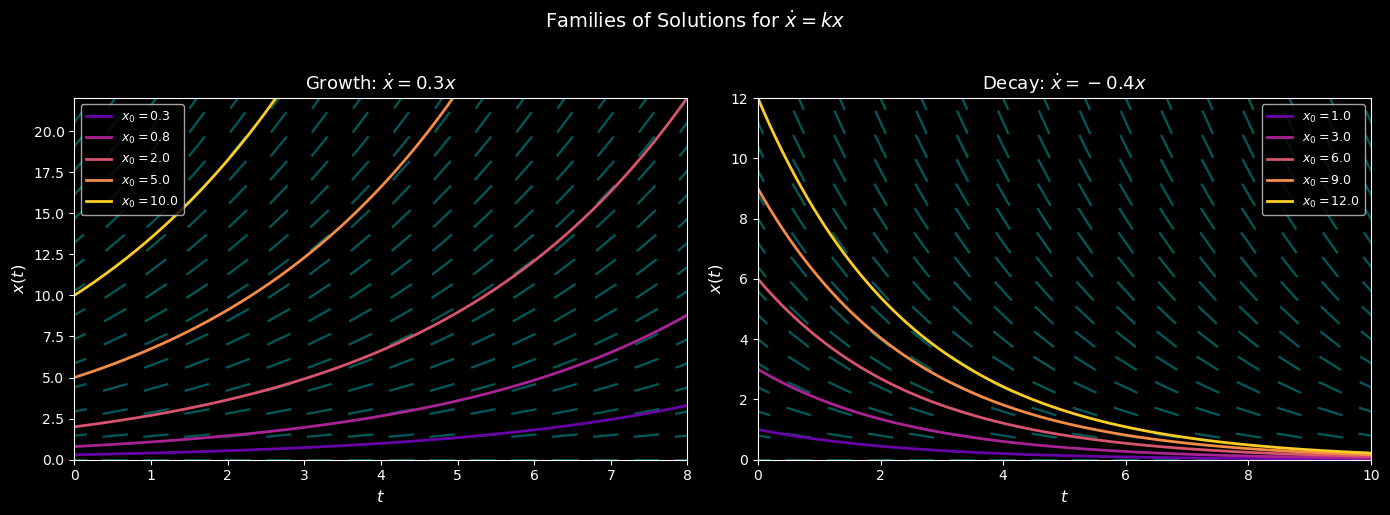

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Exponential growth ---
k_grow = 0.3
f_grow = lambda t, x: k_grow * x
plot_slope_field(f_grow, (0, 8), (0, 22), ax1, n=16, alpha=0.35)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, 5))
for x0_val, col in zip([0.3, 0.8, 2.0, 5.0, 10.0], colors):
    sol = solve_ivp(f_grow, (0, 8), [x0_val], dense_output=True)
    t_p = np.linspace(0, 8, 300)
    ax1.plot(t_p, sol.sol(t_p)[0], lw=2, color=col, label=f'$x_0={x0_val}$')
ax1.set_xlim(0, 8); ax1.set_ylim(0, 22)
ax1.set_xlabel('$t$', fontsize=12); ax1.set_ylabel('$x(t)$', fontsize=12)
ax1.set_title(r'Growth: $\dot{x} = 0.3x$', fontsize=13)
ax1.legend(fontsize=9)

# --- Exponential decay ---
k_dec = -0.4
f_dec = lambda t, x: k_dec * x
plot_slope_field(f_dec, (0, 10), (0, 12), ax2, n=16, alpha=0.35)
for x0_val, col in zip([1.0, 3.0, 6.0, 9.0, 12.0], colors):
    sol = solve_ivp(f_dec, (0, 10), [x0_val], dense_output=True)
    t_p = np.linspace(0, 10, 300)
    ax2.plot(t_p, sol.sol(t_p)[0], lw=2, color=col, label=f'$x_0={x0_val}$')
ax2.set_xlim(0, 10); ax2.set_ylim(0, 12)
ax2.set_xlabel('$t$', fontsize=12); ax2.set_ylabel('$x(t)$', fontsize=12)
ax2.set_title(r'Decay: $\dot{x} = -0.4x$', fontsize=13)
ax2.legend(fontsize=9)

plt.suptitle('Families of Solutions for $\\dot{x} = kx$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

- An ODE $\dot{x} = f(x)$ specifies a rate of change; a **solution** is a curve $x(t)$ consistent with that rate and an initial condition.
- For $\dot{x} = kx$, the exact solution is $x(t) = x_0 e^{kt}$, derived by separation of variables.
- **Euler's method** approximates the solution by linearizing over small intervals: $x_{k+1} = x_k + h f(x_k)$. It is first-order accurate — error $\propto h$.
- **scipy's `solve_ivp`** uses adaptive Runge-Kutta, achieving much higher accuracy with comparable computational cost.
- Slope fields give geometric intuition: solution curves are tangent to the field everywhere and never cross.